# Análise de Saúde Financeira e Comprometimento de Renda
### O peso dos custos fixos e o impacto do endividamento no orçamento

Esta análise explora a "liberdade financeira" de 20.000 indivíduos, indo além de onde o dinheiro é gasto e focando no quanto da renda já está comprometida antes mesmo das escolhas de estilo de vida. O objetivo é identificar perfis com maior risco de endividamento e entender como os custos fixos (aluguel, empréstimos e seguros) impactam a renda disponível.

**Dataset:** [Indian Personal Finance and Spending Habits](https://www.kaggle.com/datasets/shriyashjagtap/indian-personal-finance-and-spending-habits)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

path = kagglehub.dataset_download("shriyashjagtap/indian-personal-finance-and-spending-habits")
csv_file = os.path.join(path, os.listdir(path)[0])

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(csv_file)

df['Fixed_Costs'] = df['Rent'] + df['Loan_Repayment'] + df['Insurance']
df['Income_Commitment_Ratio'] = (df['Fixed_Costs'] / df['Income']) * 100
df['True_Disposable_Income'] = df['Income'] - df['Fixed_Costs']

df[['Income', 'Fixed_Costs', 'Income_Commitment_Ratio', 'True_Disposable_Income']].head()

Using Colab cache for faster access to the 'indian-personal-finance-and-spending-habits' dataset.


,Income,Fixed_Costs,Income_Commitment_Ratio,True_Disposable_Income
0,44637.249636,15597.665020,34.943159,29039.584616
1,26858.596592,6241.241935,23.237409,20617.354656
2,50367.605084,14369.044199,28.528345,35998.560885
3,101455.600247,26917.199551,26.531014,74538.400696
4,24875.283548,8723.573278,35.069242,16151.710270


## 2. Comprometimento de Renda por Localização (City Tier)

O primeiro passo para entender a saúde financeira é identificar como o custo de vida regional impacta o orçamento. Diferente da ocupação profissional, o nível da cidade (Tier) dita o preço do aluguel e o acesso a serviços básicos.

Um Índice de Comprometimento de Renda (ICR) elevado indica que qualquer imprevisto financeiro pode levar o indivíduo ao endividamento. Vamos observar como morar em grandes centros (Tier 1) vs. cidades menores (Tier 3) altera drasticamente essa segurança.

/tmp/ipykernel_10561/2730175096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='City_Tier', y='Income_Commitment_Ratio', palette='magma', order=order)


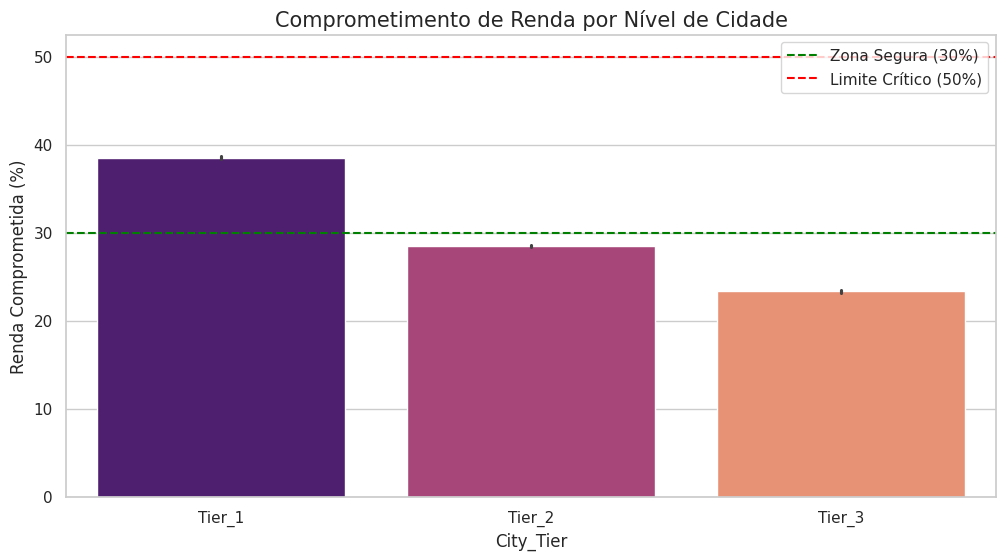

In [24]:
plt.figure(figsize=(12, 6))
order = ['Tier_1', 'Tier_2', 'Tier_3']
sns.barplot(data=df, x='City_Tier', y='Income_Commitment_Ratio', palette='magma', order=order)
plt.axhline(y=30, color='green', linestyle='--', label='Zona Segura (30%)')
plt.axhline(y=50, color='red', linestyle='--', label='Limite Crítico (50%)')
plt.title('Comprometimento de Renda por Nível de Cidade', fontsize=15)
plt.ylabel('Renda Comprometida (%)')
plt.legend()
plt.show()

O gráfico acima revela o nível de vulnerabilidade financeira de cada categoria. Note que a linha tracejada em 50% serve como um alerta: ocupações que se aproximam ou ultrapassam essa marca possuem um orçamento extremamente rígido.

Interessante notar que mesmo profissões com rendas médias potencialmente mais altas podem apresentar alto comprometimento, o que sugere que o estilo de vida e os custos fixos acompanham o crescimento da receita.

## 3. Dispersão de Custos Fixos: O Custo da Urbanização

Nesta seção, analisamos como os custos fixos se comportam à medida que a renda aumenta. O objetivo é visualizar se indivíduos com rendas maiores conseguem reduzir o peso dos custos fixos ou se o padrão de vida nas grandes cidades "consome" proporcionalmente esses ganhos.

Observamos o fenômeno do "estrangulamento" financeiro, onde a localização geográfica cria camadas distintas de gastos obrigatórios para uma mesma faixa salarial.

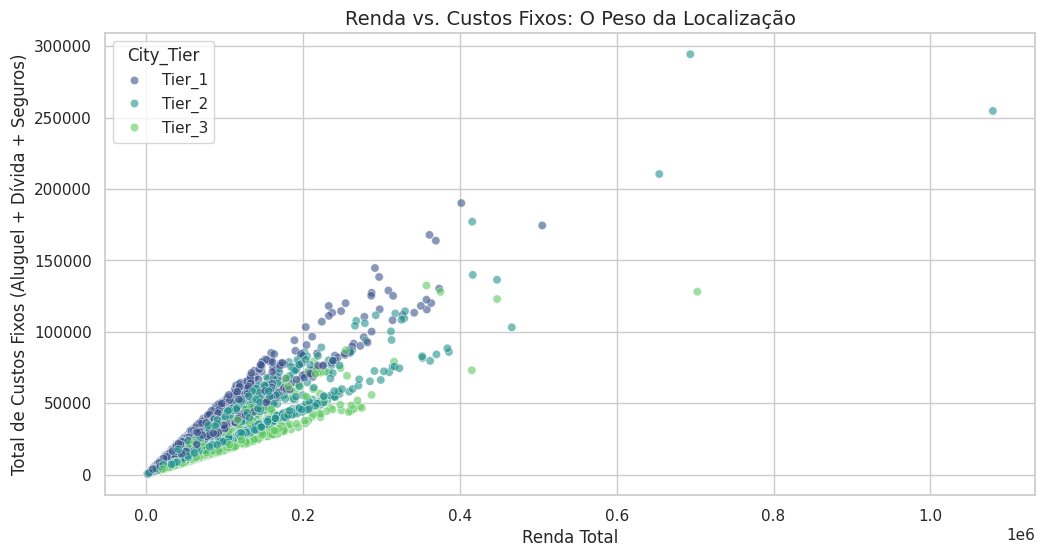

In [25]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Income', y='Fixed_Costs', hue='City_Tier', alpha=0.6, palette='viridis')
plt.title('Renda vs. Custos Fixos: O Peso da Localização', fontsize=14)
plt.xlabel('Renda Total')
plt.ylabel('Total de Custos Fixos (Aluguel + Dívida + Seguros)')
plt.show()

Os gráficos acima trazem revelações importantes:
1. **O Degrau das Cidades:** Existe uma escada clara de comprometimento de renda. Morar em uma cidade Tier 1 impõe uma carga financeira significativamente maior.
2. **Renda vs. Custos Fixos:** No gráfico de dispersão, as cores mostram nuvens separadas. Isso indica que mesmo ganhando mais, o morador da Tier 1 dificilmente terá o mesmo custo fixo de alguém da Tier 3, o que limita sua capacidade de manobra financeira.

## 4. O Impacto dos Custos Fixos na Flexibilidade Orçamentária

Para finalizar a análise técnica, vamos observar a correlação entre as principais variáveis de custo fixo. Entender como o aluguel e os empréstimos caminham juntos nos ajuda a prever o risco de insolvência de um determinado perfil.

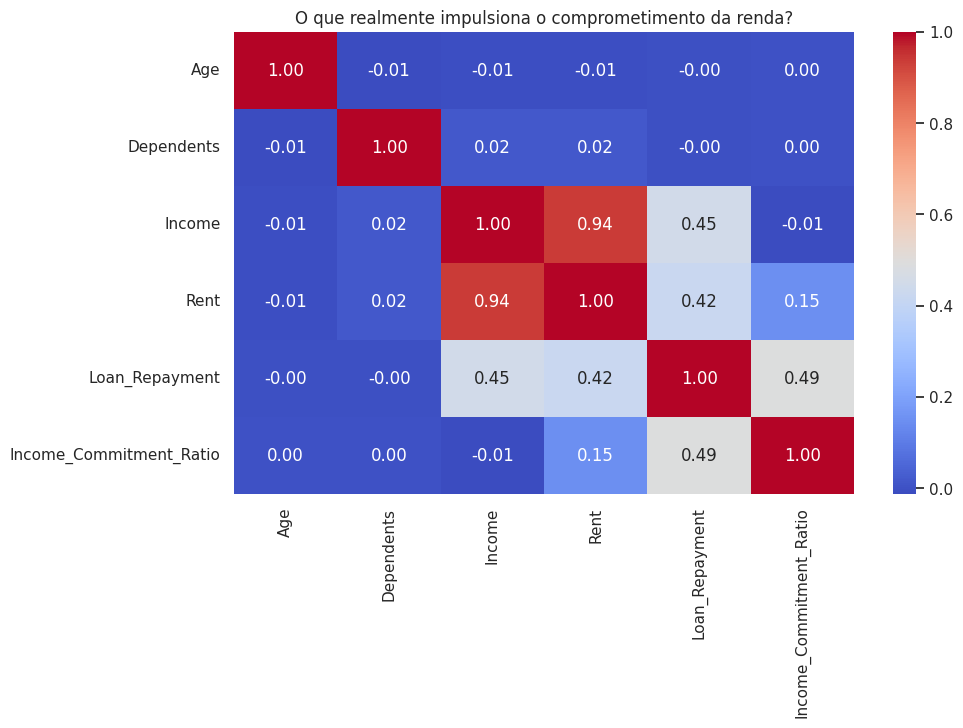

In [26]:
plt.figure(figsize=(10, 6))
# Focar em variáveis independentes para ver o que realmente impacta o ICR
vars_interesse = ['Age', 'Dependents', 'Income', 'Rent', 'Loan_Repayment', 'Income_Commitment_Ratio']
sns.heatmap(df[vars_interesse].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('O que realmente impulsiona o comprometimento da renda?')
plt.show()

## 5. Níveis de Segurança Financeira por Tipo de Cidade

Para tornar a análise ainda mais prática, vamos classificar os indivíduos em três categorias de segurança baseadas no comprometimento da renda:
* **Seguro:** Até 30% da renda comprometida com custos fixos.
* **Alerta:** Entre 30% e 50% da renda comprometida.
* **Risco:** Acima de 50% da renda comprometida.

Ao segmentar por cidade, conseguiremos ver onde o risco de insolvência financeira está realmente concentrado.

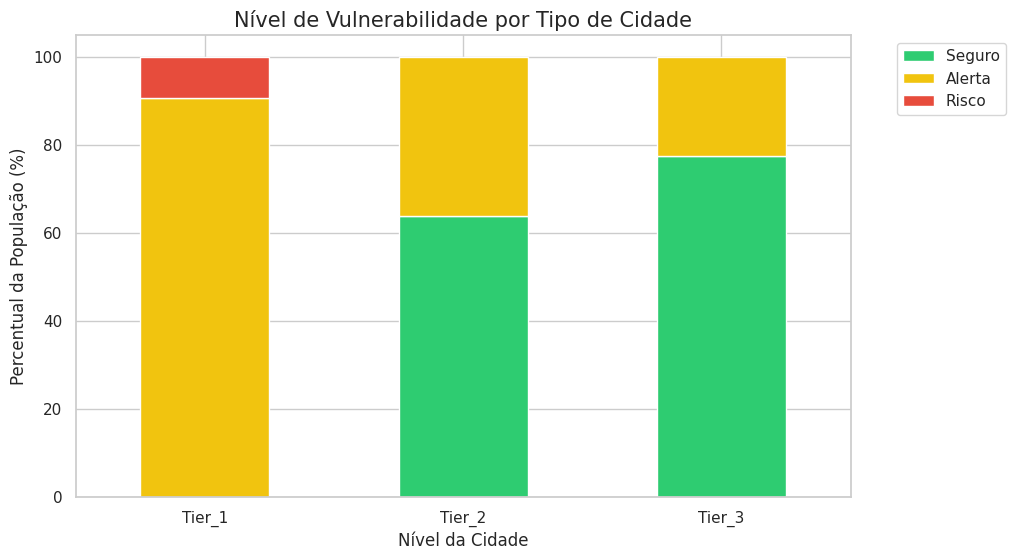

In [27]:
security_city = pd.crosstab(df['City_Tier'], df['Security_Level'], normalize='index') * 100
security_city = security_city[['Seguro', 'Alerta', 'Risco']]

security_city.plot(kind='bar', stacked=True, color=['#2ecc71', '#f1c40f', '#e74c3c'], figsize=(10, 6))
plt.title('Nível de Vulnerabilidade por Tipo de Cidade', fontsize=15)
plt.xlabel('Nível da Cidade')
plt.ylabel('Percentual da População (%)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 6. Conclusões

A análise da saúde financeira revelou que a localização geográfica é o fator mais determinante para a vulnerabilidade financeira nesta base de dados.

1.  **O Fator Localização:** Morar em cidades Tier 1 é o principal impulsionador do risco financeiro. O comprometimento médio nessas regiões é quase o dobro das cidades Tier 3, concentrando praticamente todos os casos de indivíduos em zona de "Risco".
2.  **A Armadilha do Aluguel:** O aluguel mostrou ser a variável com maior peso na rigidez do orçamento. O aumento da renda é frequentemente acompanhado por custos fixos mais altos, impedindo que o aumento salarial se transforme em segurança financeira real.
3.  **Gestão além da Renda:** A segurança financeira não é garantida apenas por uma renda alta, mas sim pelo equilíbrio entre o ganho e o custo de vida local.

Em suma, estratégias de melhoria financeira para este grupo devem focar na otimização de custos fixos em grandes centros ou na busca por maior flexibilidade geográfica, permitindo que a renda disponível real seja maximizada.